# 1.주민등록증 비식별화 하기 (EasyOCR)

In [1]:
%pip install easyocr

   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ------------------------------------ --- 2.6/2.9 MB 20.0 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 13.9 MB/s  0:00:00
   ---------------------------------------- 0.0/43.8 MB ? eta -:--:--
   --- ------------------------------------ 3.9/43.8 MB 18.2 MB/s eta 0:00:03
   -------- ------------------------------- 9.2/43.8 MB 21.5 MB/s eta 0:00:02
   ------------ --------------------------- 14.2/43.8 MB 22.1 MB/s eta 0:00:02
   ----------------- ---------------------- 19.7/43.8 MB 23.2 MB/s eta 0:00:02
   --------------------- ------------------ 23.1/43.8 MB 21.7 MB/s eta 0:00:01
   ------------------------- -------------- 28.0/43.8 MB 21.9 MB/s eta 0:00:01
   ----------------------------- ---------- 32.5/43.8 MB 22.3 MB/s eta 0:00:01
   ----------------------------------- ---- 38.5/43.8 MB 22.7 MB/s eta 0:00:01
   ------------------------------------ --- 39.8/43.8 MB 22.9 MB/s eta 0:00:01
 

In [2]:
import easyocr

In [3]:
# 이슈 해결
## 이슈 1: AttributeError: 'NoneType' object has no attribute 'shape'
### 이미지 경로 영어로 바꾸기
### mac, linux에서는 한글로 해도 됨

## 이슈 2: AttributeError: module 'cv2' has no attribute '__version__'
### 해결 방안: 깃허브로 설치
### uv remove easyocr
### uv add "easyocr @ git+https://github.com/JaidedAI/EasyOCR.git"

## 1.1.이미지 불러오기

  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------- ----------------------------- 2.4/9.3 MB 12.4 MB/s eta 0:00:01
   ---------------------- ----------------- 5.2/9.3 MB 13.1 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.3 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 12.1 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 10.5 MB/s  0:00:00
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 15.1 MB/s  0:00:00
Using ca

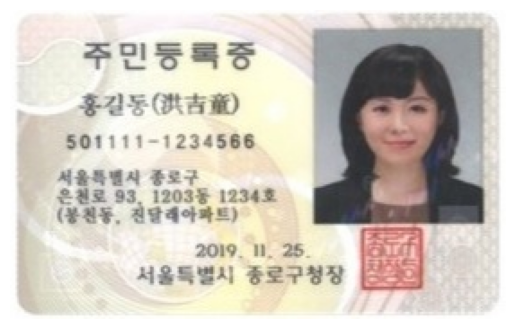

In [9]:
%pip install matplotlib
from PIL import Image
import matplotlib.pyplot as plt

image_path = r'C:\Users\playdata2\work_space(playdata)\SKN30_playdata\AI_agent\multimodal_ai\data\id_card_sample.jpg'
image = Image.open(image_path)

plt.imshow(image)
plt.axis("off")
plt.show()

## 1.2.OCR로 텍스트 추출

In [10]:
reader = easyocr.Reader(['ko', 'en'])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.1% Complete

In [11]:
reader

In [12]:
results = reader.readtext(image_path)
results

c:\Users\playdata2\miniconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[([[np.int32(37), np.int32(10)],
   [np.int32(140), np.int32(10)],
   [np.int32(140), np.int32(41)],
   [np.int32(37), np.int32(41)]],
  '주민등록증',
  np.float64(0.9944544255567526)),
 ([[np.int32(35), np.int32(43)],
   [np.int32(131), np.int32(43)],
   [np.int32(131), np.int32(63)],
   [np.int32(35), np.int32(63)]],
  '흥기동(요 표)',
  np.float64(0.07490244697651556)),
 ([[np.int32(29), np.int32(67)],
   [np.int32(79), np.int32(67)],
   [np.int32(79), np.int32(81)],
   [np.int32(29), np.int32(81)]],
  '501111',
  np.float64(0.8923105792314159)),
 ([[np.int32(83), np.int32(67)],
   [np.int32(139), np.int32(67)],
   [np.int32(139), np.int32(81)],
   [np.int32(83), np.int32(81)]],
  '1234566',
  np.float64(0.3674638837697188)),
 ([[np.int32(21), np.int32(83)],
   [np.int32(153), np.int32(83)],
   [np.int32(153), np.int32(123)],
   [np.int32(21), np.int32(123)]],
  '# 설 {93-33',
  np.float64(0.0037327636284345566)),
 ([[np.int32(65), np.int32(107)],
   [np.int32(115), np.int32(107)],
   [np.int3

## 1.3.이미지에 박스 그리기

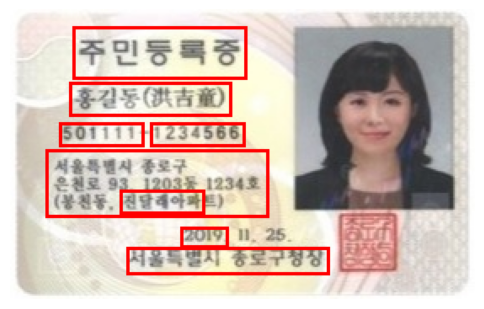

In [13]:
from PIL import ImageDraw

image_boxes = image.copy()
draw = ImageDraw.Draw(image_boxes)

for bbox, text, score in results:
    x1 = int(bbox[0][0])
    y1 = int(bbox[0][1])
    x2 = int(bbox[2][0])
    y2 = int(bbox[2][1])
    draw.rectangle(
        [x1, y1, x2, y2],
        outline="red",
        width=2
        )

plt.figure(figsize=(6, 4))
plt.imshow(image_boxes)
plt.axis("off")
plt.show()

## 1.4.주민등록번호 뒷자리 검은색 박스로 채우기

In [15]:
results[3]

([[np.int32(83), np.int32(67)],
  [np.int32(139), np.int32(67)],
  [np.int32(139), np.int32(81)],
  [np.int32(83), np.int32(81)]],
 '1234566',
 np.float64(0.3674638837697188))

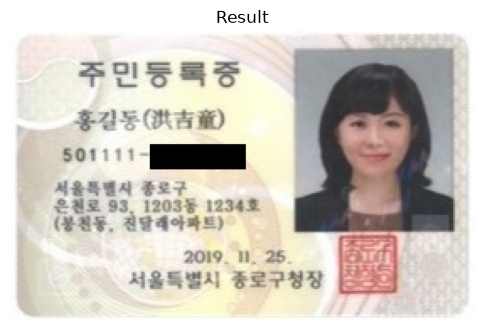

In [16]:
image_masked = image.copy()
draw = ImageDraw.Draw(image_masked)

bbox, text, score = results[3]
# 주민번호 패턴 감지 : 앞 6자리 - 뒤 7자리
x1 = int(bbox[0][0])
y1 = int(bbox[0][1])
x2 = int(bbox[2][0])
y2 = int(bbox[2][1])

draw.rectangle(
    [x1, y1, x2, y2],
    fill='black'
    )

plt.figure(figsize=(6, 4))
plt.imshow(image_masked)
plt.axis("off")
plt.title("Result")
plt.show()

In [17]:
from easyocr.utils import reformat_input
reformat = reformat_input(image)
reformat_path = reformat_input(image_path)

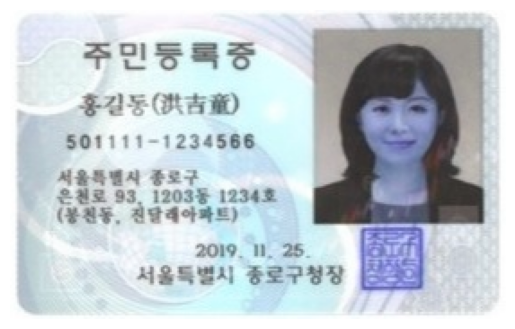

In [18]:
plt.imshow(reformat[0])
plt.axis('off')
plt.show()

# 2.만화 번역하기 (Google Vision Cloud)

In [19]:
%pip install google-cloud-vision

  Using cached proto_plus-1.28.0-py3-none-any.whl.metadata (2.2 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyasn1-0.6.3-py3-none-any.whl.metadata (8.4 kB)
   ---------------------------------------- 0.0/542.2 kB ? eta -:--:--
   ---------------------------------------- 542.2/542.2 kB 6.4 MB/s  0:00:00
   ---------------------------------------- 0.0/5.0 MB ? eta -:--:--
   ------------------------- -------------- 3.1/5.0 MB 17.8 MB/s eta 0:00:01
   ---------------------------------------  5.0/5.0 MB 12.4 MB/s eta 0:00:01
   ---------------------------------------- 5.0/5.0 MB 10.5 MB/s  0:00:00
Using cached proto_plus-1.28.0-py3-none-any.whl (50 kB)
Using cached pyasn1_modules-0.4.2-py3-none-any.whl (181 kB)
Using cached pyasn1-0.6.3-py3-none-any.whl (83 kB)

  Attempting uninstall: protobuf

    Found existing installation: protobuf 5.29.6

   ---- ----------------------------------- 1/9 [protobuf]
    Uninstalling protobuf-5.29.6:
   ---- 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.34.1 requires protobuf<6.0,>=5.0, but you have protobuf 7.35.1 which is incompatible.


In [20]:
from google.cloud import vision

## 2.1.서비스 계정 키 경로 설정

In [35]:
import os
from pathlib import Path

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\Users\playdata2\work_space(playdata)\SKN30_playdata\AI_agent\multimodal_ai\fleet-tractor-501707-g0-2247af75a760.json"

## 2.2.클라이언트 불러오기

In [36]:
client = vision.ImageAnnotatorClient()

## 2.3.이미지 출력하기

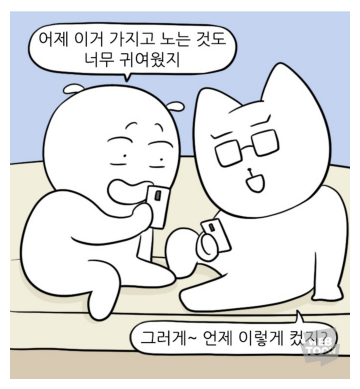

In [39]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = r"C:\Users\playdata2\work_space(playdata)\SKN30_playdata\AI_agent\multimodal_ai\data\webtoon.jpeg"

image = Image.open(image_path)

plt.imshow(image)
plt.axis("off")
plt.show()

## 2.4.OCR 추출하기

In [41]:
with open(image_path, "rb") as f:
    content = f.read()

vision_image = vision.Image(content=content)
response = client.text_detection(image=vision_image)

response

text_annotations {
  locale: "ko"
  description: "\"어제 이거 가지고 노는 것도\n너무 귀여웠지\n그러게~ 언제 이렇게 컸지?\nTOOK"
  bounding_poly {
    vertices {
      x: 49
      y: 43
    }
    vertices {
      x: 662
      y: 43
    }
    vertices {
      x: 662
      y: 702
    }
    vertices {
      x: 49
      y: 702
    }
  }
}
text_annotations {
  description: "\""
  bounding_poly {
    vertices {
      x: 49
      y: 43
    }
    vertices {
      x: 65
      y: 43
    }
    vertices {
      x: 65
      y: 76
    }
    vertices {
      x: 49
      y: 76
    }
  }
}
text_annotations {
  description: "어제"
  bounding_poly {
    vertices {
      x: 58
      y: 43
    }
    vertices {
      x: 116
      y: 43
    }
    vertices {
      x: 116
      y: 76
    }
    vertices {
      x: 58
      y: 76
    }
  }
}
text_annotations {
  description: "이거"
  bounding_poly {
    vertices {
      x: 131
      y: 43
    }
    vertices {
      x: 187
      y: 43
    }
    vertices {
      x: 187
      y: 76
    }
    vert

In [44]:
annotations = response.text_annotations
annotations

[locale: "ko"
description: "\"어제 이거 가지고 노는 것도\n너무 귀여웠지\n그러게~ 언제 이렇게 컸지?\nTOOK"
bounding_poly {
  vertices {
    x: 49
    y: 43
  }
  vertices {
    x: 662
    y: 43
  }
  vertices {
    x: 662
    y: 702
  }
  vertices {
    x: 49
    y: 702
  }
}
, description: "\""
bounding_poly {
  vertices {
    x: 49
    y: 43
  }
  vertices {
    x: 65
    y: 43
  }
  vertices {
    x: 65
    y: 76
  }
  vertices {
    x: 49
    y: 76
  }
}
, description: "어제"
bounding_poly {
  vertices {
    x: 58
    y: 43
  }
  vertices {
    x: 116
    y: 43
  }
  vertices {
    x: 116
    y: 76
  }
  vertices {
    x: 58
    y: 76
  }
}
, description: "이거"
bounding_poly {
  vertices {
    x: 131
    y: 43
  }
  vertices {
    x: 187
    y: 43
  }
  vertices {
    x: 187
    y: 76
  }
  vertices {
    x: 131
    y: 76
  }
}
, description: "가지고"
bounding_poly {
  vertices {
    x: 203
    y: 43
  }
  vertices {
    x: 294
    y: 43
  }
  vertices {
    x: 294
    y: 76
  }
  vertices {
    x: 203
    y: 76
  

In [45]:
annotations[0].description  # 전체 OCR 텍스트

'"어제 이거 가지고 노는 것도\n너무 귀여웠지\n그러게~ 언제 이렇게 컸지?\nTOOK'

In [46]:
annotations[1:] # 개별 단어/문장 OCR 결과

[description: "\""
 bounding_poly {
   vertices {
     x: 49
     y: 43
   }
   vertices {
     x: 65
     y: 43
   }
   vertices {
     x: 65
     y: 76
   }
   vertices {
     x: 49
     y: 76
   }
 },
 description: "어제"
 bounding_poly {
   vertices {
     x: 58
     y: 43
   }
   vertices {
     x: 116
     y: 43
   }
   vertices {
     x: 116
     y: 76
   }
   vertices {
     x: 58
     y: 76
   }
 },
 description: "이거"
 bounding_poly {
   vertices {
     x: 131
     y: 43
   }
   vertices {
     x: 187
     y: 43
   }
   vertices {
     x: 187
     y: 76
   }
   vertices {
     x: 131
     y: 76
   }
 },
 description: "가지고"
 bounding_poly {
   vertices {
     x: 203
     y: 43
   }
   vertices {
     x: 294
     y: 43
   }
   vertices {
     x: 294
     y: 76
   }
   vertices {
     x: 203
     y: 76
   }
 },
 description: "노는"
 bounding_poly {
   vertices {
     x: 305
     y: 43
   }
   vertices {
     x: 366
     y: 43
   }
   vertices {
     x: 366
     y: 76
   }
   vertices

## 2.5.이미지에 박스 그리기

In [48]:
from PIL import ImageDraw

image_boxes = image.copy()
draw = ImageDraw.Draw(image_boxes)

for annot in annotations[1:]:
    v = annot.bounding_poly.vertices
    print(v)
    print("=====")
    print(v[0].x, v[0].y, "|", v[1].x, v[1].y, "|", v[2].x, v[2].y, "|", v[3].x, v[3].y)
    print("="*100)

    x1 = v[0].x
    y1 = v[0].y
    x2 = v[2].x
    y2 = v[2].y

    draw.rectangle([x1, y1, x2, y2], outline="red", width=2)

[x: 49
y: 43
, x: 65
y: 43
, x: 65
y: 76
, x: 49
y: 76
]
=====
49 43 | 65 43 | 65 76 | 49 76
[x: 58
y: 43
, x: 116
y: 43
, x: 116
y: 76
, x: 58
y: 76
]
=====
58 43 | 116 43 | 116 76 | 58 76
[x: 131
y: 43
, x: 187
y: 43
, x: 187
y: 76
, x: 131
y: 76
]
=====
131 43 | 187 43 | 187 76 | 131 76
[x: 203
y: 43
, x: 294
y: 43
, x: 294
y: 76
, x: 203
y: 76
]
=====
203 43 | 294 43 | 294 76 | 203 76
[x: 305
y: 43
, x: 366
y: 43
, x: 366
y: 76
, x: 305
y: 76
]
=====
305 43 | 366 43 | 366 76 | 305 76
[x: 377
y: 43
, x: 438
y: 43
, x: 438
y: 76
, x: 377
y: 76
]
=====
377 43 | 438 43 | 438 76 | 377 76
[x: 151
y: 85
, x: 211
y: 85
, x: 211
y: 117
, x: 151
y: 117
]
=====
151 85 | 211 85 | 211 117 | 151 117
[x: 221
y: 85
, x: 315
y: 85
, x: 315
y: 117
, x: 221
y: 117
]
=====
221 85 | 315 85 | 315 117 | 221 117
[x: 315
y: 85
, x: 342
y: 85
, x: 342
y: 117
, x: 315
y: 117
]
=====
315 85 | 342 85 | 342 117 | 315 117
[x: 266
y: 651
, x: 356
y: 651
, x: 356
y: 683
, x: 266
y: 683
]
=====
266 651 | 356 651 | 

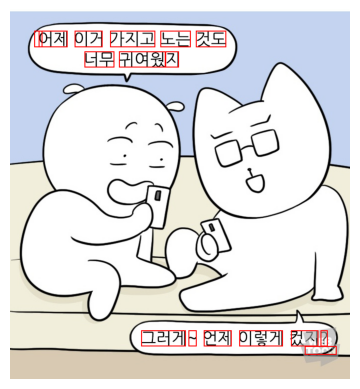

In [49]:
plt.imshow(image_boxes)
plt.axis("off")
plt.show()

## 2.6.번역하기

In [50]:
%pip install translate


   ---------------------------------------- 2/2 [translate]

Note: you may need to restart the kernel to use updated packages.


In [51]:
annotations[0].description

'"어제 이거 가지고 노는 것도\n너무 귀여웠지\n그러게~ 언제 이렇게 컸지?\nTOOK'

In [52]:
from translate import  Translator

translator = Translator(from_lang='ko', to_lang='en')

# \n 으로 나누면 말풍선 덩어리 단위로 분리됨
chunks = []
for line in annotations[0].description.strip().split("\n"):
    if line.strip():
        chunks.append(line)
print("[Chunks]")
print(chunks)

print("=== 원문 → 번역 ===")
translations = {}
for chunk in chunks:
    translated = translator.translate(chunk)
    translations[chunk] = translated
    print(f"{chunk}  →  {translated}")

[Chunks]
['"어제 이거 가지고 노는 것도', '너무 귀여웠지', '그러게~ 언제 이렇게 컸지?', 'TOOK']
=== 원문 → 번역 ===
"어제 이거 가지고 노는 것도  →  "Playing with this yesterday
너무 귀여웠지  →  It was so cute
그러게~ 언제 이렇게 컸지?  →  Yeah ~ When did she grow up like this?
TOOK  →  Toook


In [53]:
translations

{'"어제 이거 가지고 노는 것도': '"Playing with this yesterday',
 '너무 귀여웠지': 'It was so cute',
 '그러게~ 언제 이렇게 컸지?': 'Yeah ~ When did she grow up like this?',
 'TOOK': 'Toook'}

## 2.7.번역 이미지에 나타내기

In [54]:
# annot_dict: 단어 → [x1, y1, x2, y2]
annot_dict = {}
for ann in annotations[1:]:
    v = ann.bounding_poly.vertices
    annot_dict[ann.description] = [v[0].x, v[0].y, v[2].x, v[2].y]

annot_dict

{'"': [49, 43, 65, 76],
 '어제': [58, 43, 116, 76],
 '이거': [131, 43, 187, 76],
 '가지고': [203, 43, 294, 76],
 '노는': [305, 43, 366, 76],
 '것도': [377, 43, 438, 76],
 '너무': [151, 85, 211, 117],
 '귀여웠': [221, 85, 315, 117],
 '지': [315, 85, 342, 117],
 '그러게': [266, 651, 356, 683],
 '~': [362, 651, 378, 683],
 '언제': [393, 651, 449, 683],
 '이렇게': [465, 651, 553, 683],
 '컸지': [570, 651, 625, 683],
 '?': [630, 651, 644, 683],
 'TOOK': [598, 683, 662, 700]}

In [55]:
chunks

['"어제 이거 가지고 노는 것도', '너무 귀여웠지', '그러게~ 언제 이렇게 컸지?', 'TOOK']

In [56]:
# chunk_data: OCR로 추출한 텍스트를 이미지 내 실제 위치 정보와 연결해서 저장하는 과정
# 목표: 각 번역할 문장(chunk)이 이미지에서 어느 박스 영역에 해당하는지 좌표를 계산한다.
import re

# 같은 줄로 판단할 y좌표의 허용 오차
Y_TOL = 20

# 최종 결과를 저장할 리스트
chunk_data = []

# chunks: OCR 결과에서 줄 단위로 나뉜 텍스트 목록
for chunk in chunks:
    # 1) 특수문자 제거 후 공백 기준으로 단어를 나눈다.
    #    예: "안녕! 세계" -> "안녕 세계"
    clean = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', chunk).strip()
    words = clean.split()

    # 2) 이 청크가 이미지에서 어느 세로 위치에 있는지 찾는다.
    #    - annot_dict에는 단어/문장 -> [x1, y1, x2, y2] 형태로 박스 좌표가 들어 있다.
    #    - 청크 안의 단어들 중 하나라도 annot_dict와 매칭되면 그 단어의 y 중심값을 기준으로 사용한다.
    anchor_y = None
    for word in words:
        for key, coords in annot_dict.items():
            # annotation 텍스트도 특수문자 제거해서 비교하기 쉽게 만든다.
            clean_key = re.sub(r'[^가-힣a-zA-Z0-9]', '', key)

            # 단어가 정확히 일치하거나, annotation 텍스트 안에 포함되면 같은 줄로 판단한다.
            if clean_key and (word == clean_key or clean_key in word):
                # 박스의 세로 중앙값을 기준 y값으로 사용한다.
                anchor_y = (coords[1] + coords[3]) // 2
                break
        if anchor_y:
            break

    # 3) 기준 y값이 없으면 이 청크는 건너뛰고 다음 청크로 넘어간다.
    if anchor_y is None:
        continue

    # 4) anchor_y 주변에 있는 annotation만 같은 줄로 묶는다.
    #    즉, 한 줄에 있는 단어 박스들을 모아서 하나의 큰 박스로 만든다.
    same_line = [c for c in annot_dict.values()
                 if abs((c[1] + c[3]) // 2 - anchor_y) <= Y_TOL]

    # 5) 같은 줄에 있는 박스들의 좌표를 합쳐서 하나의 통합 박스(box)를 만든다.
    #    - x1: 가장 왼쪽
    #    - y1: 가장 위쪽
    #    - x2: 가장 오른쪽
    #    - y2: 가장 아래쪽
    chunk_data.append({
        "text": chunk,
        "translate": translations.get(chunk, ""),
        "box": [
            min(c[0] for c in same_line),
            min(c[1] for c in same_line),
            max(c[2] for c in same_line),
            max(c[3] for c in same_line),
        ]
    })

# 최종 결과 확인: 각 청크마다 번역문과 이미지 박스 좌표가 들어 있다.
chunk_data

[{'text': '"어제 이거 가지고 노는 것도',
  'translate': '"Playing with this yesterday',
  'box': [49, 43, 438, 76]},
 {'text': '너무 귀여웠지',
  'translate': 'It was so cute',
  'box': [151, 85, 342, 117]},
 {'text': '그러게~ 언제 이렇게 컸지?',
  'translate': 'Yeah ~ When did she grow up like this?',
  'box': [266, 651, 644, 683]},
 {'text': 'TOOK', 'translate': 'Toook', 'box': [598, 683, 662, 700]}]

In [ ]:
# 이미지에 합성
from PIL import ImageFont

# 로컬
# FONT_PATH = "C:/Windows/Fonts/Arial.ttf"

#Colab
FONT_PATH = "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf"
FONT_SIZE = 25
font = ImageFont.truetype(FONT_PATH, FONT_SIZE)

image_translated = image.copy()
draw = ImageDraw.Draw(image_translated)

for item in chunk_data:
    x1, y1, x2, y2 = item["box"]
    draw.rectangle([x1, y1, x2, y2], fill="white", outline="red")
    draw.text((x1 + 2, y1 + 2), item["translate"], font=font, fill="black")

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(image_translated)
axes[1].set_title("Translate")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## [실습]
1. OCR 전처리 개선
2. 자동 마스킹 함수 만들기
3. EasyOCR vs Google Vision vs 멀티모달 모델 비교
4. 다른 웹툰 이미지로 OCR 및 번역 실습 진행
5. OCR 결과를 CSV로 저장하기
6. 여러 이미지 일괄 OCR 처리 파이프라인 만들기